Inputs shape: (25, 4)
Outputs shape: (25,)
First 20 rows of raw data:
       var-1     var-2     var-3     var-4        yield  source
24  0.263058  0.962540  0.979484  1.057644  4564.328857  week-5
22  0.272727  0.848484  0.848485  0.818182  1118.872547  week-3
15  0.224189  0.846480  0.879484  0.878516  1088.859618    file
20  0.183674  0.857143  0.816327  0.877551   872.307487  week-1
21  0.272727  0.848484  0.848485  0.818182   743.118248  week-2
18  0.119879  0.862540  0.643331  0.849804   431.612757    file
23  0.242085  0.848724  0.469207  0.893286   386.681874  week-4
14  0.438933  0.774092  0.378167  0.933696   355.806818    file
4   0.836478  0.193610  0.663893  0.785649   258.370525    file
9   0.463442  0.630025  0.107906  0.957644   233.223610    file
7   0.352356  0.322242  0.116979  0.473113   109.571876    file
13  0.511142  0.817957  0.728710  0.112354    79.729130    file
5   0.683432  0.118663  0.829046  0.567577    78.434389    file
0   0.191447  0.038193  0.607418  

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 0.138000, Val Loss: 4.323295
Epoch 50/500, Train Loss: 0.007839, Val Loss: 2.977475
Epoch 100/500, Train Loss: 0.001261, Val Loss: 2.576084
Epoch 150/500, Train Loss: 0.000057, Val Loss: 2.446292
Epoch 200/500, Train Loss: 0.000000, Val Loss: 2.421022
Epoch 250/500, Train Loss: 0.000000, Val Loss: 2.420739
Early stopping at epoch 256, best val_loss=2.420605


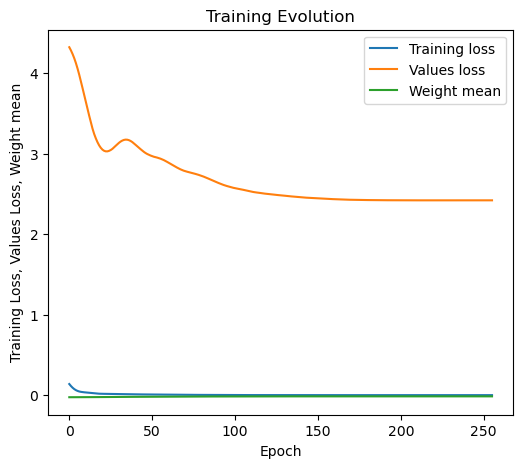

Using 4 dimensions, grid size per axis: 100, downsample: True, stride: 4
Points before downsampling: 100000000
Points after downsampling: 390625
Final grid shape: (390625, 4)
Filtered 1503 candidates near decision boundary (|margin| < 0.2)
Excluded 389122 candidates from consideration
Final grid shape after filtering: (1503, 4)
Predictions range (scaled): -0.2002 to 0.8166
Inverse-transforming predictions to raw units
Predictions range (raw): 246.6032 to 1170.1278
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.79759939, 0.77548364, 1.04707539, 1.12286691]), 'score': 3.759234916217993e-11, 'dim': 4, 'predicted_y': 1170.1278}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.79759939, 0.77548364, 1.04707539, 1.12286691]), 'score': 3.347130614452183e-11, 'dim': 4, 'predicted_y': 1170.1278}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.79759939, 0.77548364, 1.04707539, 1.12286691]), 'score': 3.174351876502767e-12, 'dim': 4,

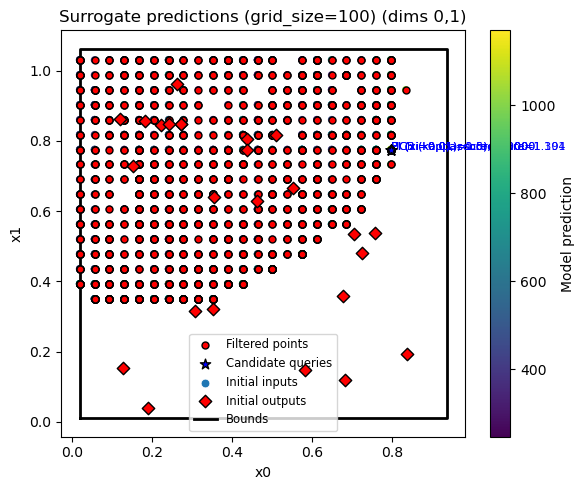

<Figure size 600x500 with 0 Axes>

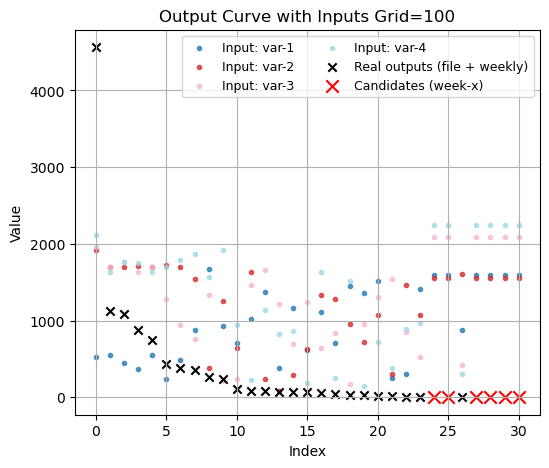

Saved dataframe to: results/run_2025-12-11 14-48-48/df_grid_100_stride4_gp_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.79759939, 0.77548364, 1.04707539, 1.12286691]), 'score': 1.390691076060035, 'dim': 4, 'predicted_y': 1170.1278}
       var-1     var-2     var-3     var-4         yield  source  yield-scaled
0   0.263058  0.962540  0.979484  1.057644  4.564329e+03  week-5  1.000000e+01
1   0.272727  0.848484  0.848485  0.818182  1.118873e+03  week-3  2.451341e+00
2   0.224189  0.846480  0.879484  0.878516  1.088860e+03    file  2.385585e+00
3   0.183674  0.857143  0.816327  0.877551  8.723075e+02  week-1  1.911141e+00
4   0.272727  0.848484  0.848485  0.818182  7.431182e+02  week-2  1.628100e+00
5   0.119879  0.862540  0.643331  0.849804  4.316128e+02    file  9.456215e-01
6   0.242085  0.848724  0.469207  0.893286  3.866819e+02  week-4  8.471823e-01
7   0.438933  0.774092  0.378167  0.933696  3.558068e+02    file  7.795381e-01
8 

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))